# TB Treatment Outcome Prediction — Improved Models (SMOTE + Extended Features)

**Dataset:** TB Case Notifications, Cordillera Administrative Region (CAR), Philippines (2015–2025)  
**Task:** Binary classification — predict **Treatment Success** vs **Treatment Failure**  
**Approach:** Improve on baseline with SMOTE oversampling and additional features

### Improvements over Baseline

| # | Improvement | Why |
|---|---|---|
| 1 | **Extra pre-encoded features** | Add City/Municipality, Treatment Health Facility, and other encoded columns not in baseline |
| 2 | **Derived delay feature** | Diagnosis → Treatment delay (only derivable date pair remaining in ml-ready) |
| 3 | **SMOTE oversampling** | Synthetically balances Failure class (13.8%) so models genuinely learn to detect failures |

> **Focus metric: Recall on Failure class** — for a CDSS, missing a likely failure is more harmful than a false alarm.

## 1. Setup and Imports

In [47]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Sklearn — preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

# Sklearn — metrics
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Utilities
import time
import joblib
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output directories
img_dir = Path('improved_outputs/images')
model_dir = Path('improved_outputs/models')
img_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Data Loading and Target Engineering

In [48]:
# Load the ML-ready dataset (features already label-encoded + standard-scaled)
df_raw = pd.read_csv('../dataset/non-temporal/2015-2025-ml-ready.csv')
print(f'ML-ready dataset shape: {df_raw.shape}')

# ── Decode Outcome/Status back to original labels ─────────────────────────
OUTCOME_LABELS_ALPHA = [
    'CURED', 'DIAGNOSED', 'DIED', 'EXCLUDED', 'FAILED', 'LOST TO FF-UP',
    'NOT ENROLLED', 'NOT EVALUATED', 'ON TREATMENT', 'Screened', 'TREATMENT COMPLETED'
]
outcome_encoded_sorted = sorted(df_raw['Outcome/Status'].dropna().unique())
OUTCOME_DECODE = dict(zip(outcome_encoded_sorted, OUTCOME_LABELS_ALPHA))
df_raw['Outcome_Label'] = df_raw['Outcome/Status'].map(OUTCOME_DECODE)

# Define target variable
SUCCESS_OUTCOMES = {'TREATMENT COMPLETED', 'CURED'}
FAILURE_OUTCOMES = {'DIED', 'LOST TO FF-UP', 'FAILED'}

df = df_raw[df_raw['Outcome_Label'].isin(SUCCESS_OUTCOMES | FAILURE_OUTCOMES)].copy()
df['Target'] = df['Outcome_Label'].apply(lambda x: 1 if x in SUCCESS_OUTCOMES else 0)

print(f'Usable records: {len(df):,}')
class_counts = df['Target'].value_counts()
print(f"  Success (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"  Failure (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.1f}%)")

ML-ready dataset shape: (7389, 28)
Usable records: 6,797
  Success (1): 5,858 (86.2%)
  Failure (0): 939 (13.8%)


## 3. Feature Engineering (Extended Features + Derived Delay)

In [49]:
# ── Derive delay feature from remaining date-string columns ───────────────
# In ml-ready.csv, only 'Date Started Tx' and 'Date of Diagnosis' are still date strings.
df['_Date_Started_Tx'] = pd.to_datetime(df['Date Started Tx'], errors='coerce')
df['_Date_of_Diagnosis'] = pd.to_datetime(df['Date of Diagnosis'], errors='coerce')

df['Diagnosis_to_Treatment_days'] = (
    df['_Date_Started_Tx'] - df['_Date_of_Diagnosis']
).dt.days.clip(lower=0)

non_null = df['Diagnosis_to_Treatment_days'].notna().sum()
print(f'Derived delay feature:')
print(f"  Diagnosis_to_Treatment_days: {non_null:,}/{len(df):,} non-null ({non_null/len(df)*100:.1f}%)")

Derived delay feature:
  Diagnosis_to_Treatment_days: 2,914/6,797 non-null (42.9%)


In [ ]:
# ── Improved feature set ───────────────────────────────────────────────────
# Baseline features + additional pre-encoded geographic/facility features + delay feature
IMP_FEATURES = [
    # --- Baseline features (all pre-encoded & scaled) ---
    'Age',
    'Days_To_Treatment',
    'Year',
    'Sex',
    'Anatomical Site',
    'Registration Group',
    'Bacteriologic Status',
    'Microscopy Result',
    'Source of Patient',
    'Type',
    'Province',
    'City/Municipality',
    'Treatment Health Facility',
    'Screening/Diagnosing Health Facility',
    # --- Derived delay feature (raw days, needs scaling) ---
    'Diagnosis_to_Treatment_days',
]

X = df[IMP_FEATURES].copy()
y = df['Target'].values

# Fill Age from Computed_Age where missing
X['Age'] = X['Age'].fillna(df['Computed_Age'])

print(f'Improved feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'  Pre-encoded ({len(IMP_FEATURES)-1}): already scaled from ml-ready.csv')
print(f'  Derived (1): Diagnosis_to_Treatment_days (raw days, will be imputed+scaled)')
print(f'\nMissing values:')
print(X.isnull().sum())

Improved feature matrix: 6,797 rows × 15 features
  Pre-encoded (14): already scaled from ml-ready.csv
  Derived (1): Diagnosis_to_Treatment_days (raw days, will be imputed+scaled)

Missing values:
Age                                        0
Days_To_Treatment                          0
Year                                       0
Sex                                        0
Anatomical Site                            0
Registration Group                         0
Bacteriologic Status                       0
Microscopy Result                          0
Source of Patient                          0
Type                                       0
Province                                   0
City/Municipality                          0
Treatment Health Facility                  0
Screening/Diagnosing Health Facility       0
Diagnosis_to_Treatment_days             3883
dtype: int64


## 4. Preprocessing Pipeline

In [51]:
# ── Improved preprocessing pipeline ───────────────────────────────────────
# Most features are already scaled; the derived delay feature needs scaling too.
PRE_ENCODED_FEATURES = [f for f in IMP_FEATURES if f != 'Diagnosis_to_Treatment_days']
DERIVED_FEATURES = ['Diagnosis_to_Treatment_days']

preprocessor = ColumnTransformer(transformers=[
    ('passthrough', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
    ]), PRE_ENCODED_FEATURES),
    ('derived', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), DERIVED_FEATURES),
])

# ── Stratified train/test split ────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Failure class in train: {(y_train == 0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'Failure class in test : {(y_test == 0).sum():,} ({(y_test==0).mean()*100:.1f}%)')

Train: 5,437  |  Test: 1,360
Failure class in train: 751 (13.8%)
Failure class in test : 188 (13.8%)


## 5. Model Training with SMOTE

In [52]:

# ── Helper: extract iteration / epoch count from a fitted estimator ────────
def get_iterations(clf):
    """
    Return the number of iterations (epochs) or trees for a fitted model.
      • Iterative  (LR, MLP, SVM) : n_iter_ until convergence / early-stop
      • Ensemble   (RF, ET, GB)   : n_estimators (trees / boosting stages)
      • Boosting   (XGB, LGB)     : n_estimators (configured stages)
      • AdaBoost                  : n_estimators_ (actual estimators used)
      • Non-iterative (KNN, NB, DT): '—'
    """
    if hasattr(clf, 'n_iter_'):
        ni = clf.n_iter_
        if hasattr(ni, '__len__'):
            return int(max(ni))   # MLP → max epochs; SVM → max across classes
        return int(ni)            # LR  → scalar iterations to convergence
    if hasattr(clf, 'n_estimators_'):
        return int(clf.n_estimators_)   # AdaBoost: actual estimators used
    if hasattr(clf, 'n_estimators'):
        return int(clf.n_estimators)    # RF, GB, XGB, LGB
    return '—'


# ── Train improved models with SMOTE ──────────────────────────────────────
IMP_MODELS = {
    'Logistic Regression + SMOTE': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight=None
    ),
    'Random Forest + SMOTE': RandomForestClassifier(
        n_estimators=300, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting + SMOTE': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'XGBoost + SMOTE': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='logloss',
        n_jobs=-1, verbosity=0
    ),
    'LightGBM + SMOTE': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)

imp_results = []
imp_trained_pipelines = {}

for name, model in IMP_MODELS.items():
    print(f'Training {name}...', end='  ', flush=True)
    t0 = time.time()

    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote',        smote),
        ('classifier',   model),
    ])
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    clf = pipe.named_steps['classifier']
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred,
                                   target_names=['Failure', 'Success'],
                                   output_dict=True, zero_division=0)
    imp_results.append({
        'Model':               name,
        'Accuracy':            accuracy_score(y_test, y_pred),
        'ROC-AUC':             roc_auc_score(y_test, y_proba),
        'F1 (Failure)':        report['Failure']['f1-score'],
        'Recall (Failure)':    report['Failure']['recall'],
        'Precision (Failure)': report['Failure']['precision'],
        'F1 (Success)':        report['Success']['f1-score'],
        'Recall (Success)':    report['Success']['recall'],
        'Train Time (s)':      round(train_time, 2),
        'Iterations / Trees':  get_iterations(clf),
    })
    imp_trained_pipelines[name] = pipe
    print(f'done ({train_time:.1f}s,  iters/trees={get_iterations(clf)})')

imp_df = pd.DataFrame(imp_results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
imp_df.index += 1

display_cols = ['Model', 'ROC-AUC', 'Recall (Failure)', 'F1 (Failure)',
                'Recall (Success)', 'Accuracy', 'Train Time (s)', 'Iterations / Trees']
print('\n' + '='*105)
print('IMPROVED MODELS (SMOTE + Extended Features) — sorted by ROC-AUC')
print('  Iterations/Trees: convergence iters (LR) | n_estimators (ensemble)')
print('='*105)
print(imp_df[display_cols].to_string())


Training Logistic Regression + SMOTE...  

done (0.0s,  iters/trees=8)
Training Random Forest + SMOTE...  done (0.9s,  iters/trees=300)
Training Gradient Boosting + SMOTE...  done (4.4s,  iters/trees=300)
Training XGBoost + SMOTE...  done (0.6s,  iters/trees=300)
Training LightGBM + SMOTE...  done (1.3s,  iters/trees=300)

IMPROVED MODELS (SMOTE + Extended Features) — sorted by ROC-AUC
  Iterations/Trees: convergence iters (LR) | n_estimators (ensemble)
                         Model   ROC-AUC  Recall (Failure)  F1 (Failure)  Recall (Success)  Accuracy  Train Time (s)  Iterations / Trees
1    Gradient Boosting + SMOTE  0.698597          0.180851      0.257576          0.964164  0.855882            4.39                 300
2              XGBoost + SMOTE  0.698501          0.164894      0.223022          0.949659  0.841176            0.63                 300
3        Random Forest + SMOTE  0.697930          0.303191      0.297650          0.882253  0.802206            0.85                 300
4             LightGBM + SMOTE  0.691

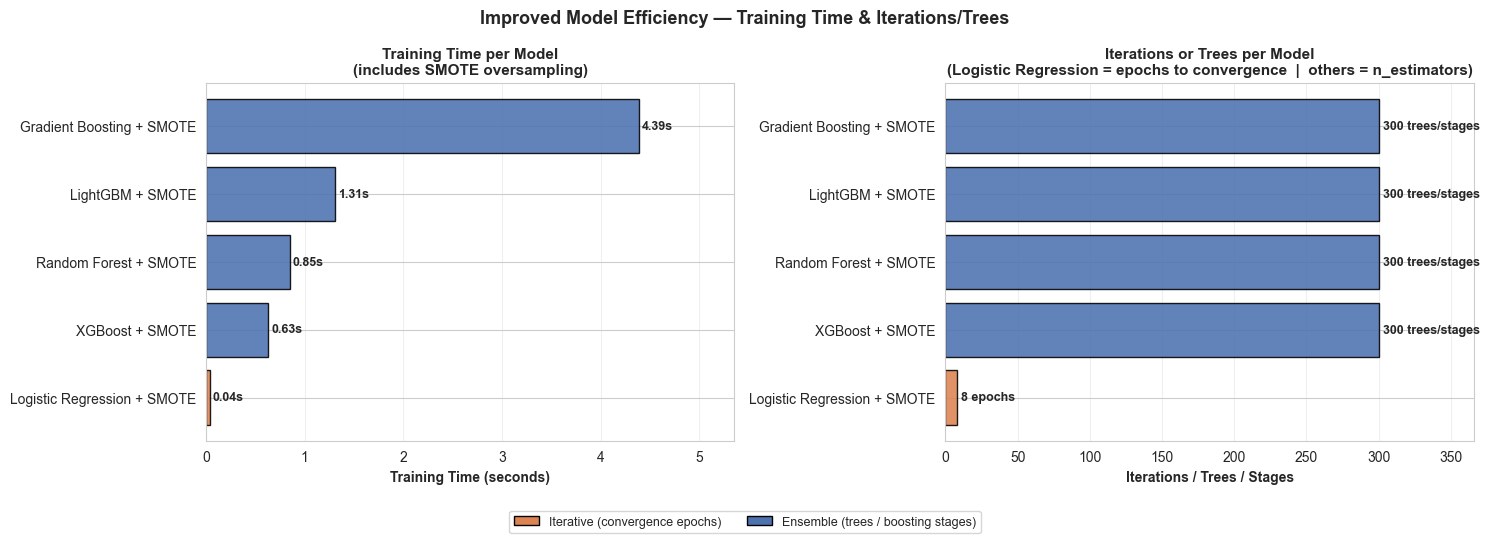

Saved: training_time_iterations_improved.png


In [63]:

# ── Training Time & Iterations / Epochs visualisation ─────────────────────
# LR → iterations to convergence (orange)
# RF, GB, XGB, LGB → trees / boosting stages (blue)

IMP_ITERATIVE = {'Logistic Regression + SMOTE'}
IMP_CAT_COLOR = {'iterative': '#DD8452', 'ensemble': '#4C72B0'}
IMP_CAT_LABEL = {
    'iterative': 'Iterative (convergence epochs)',
    'ensemble':  'Ensemble (trees / boosting stages)',
}

def imp_model_category(name):
    return 'iterative' if name in IMP_ITERATIVE else 'ensemble'

plot_imp = (
    imp_df[['Model', 'Train Time (s)', 'Iterations / Trees']]
    .copy()
    .sort_values('Train Time (s)', ascending=True)
    .reset_index(drop=True)
)
plot_imp['Category'] = plot_imp['Model'].apply(imp_model_category)
plot_imp['Color']    = plot_imp['Category'].map(IMP_CAT_COLOR)
plot_imp['IterUnit'] = plot_imp.apply(
    lambda r: 'epochs' if r['Category'] == 'iterative' else 'trees/stages', axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Training Time ────────────────────────────────────────────────────
bars_t = axes[0].barh(
    plot_imp['Model'], plot_imp['Train Time (s)'],
    color=plot_imp['Color'], edgecolor='black', alpha=0.88
)
for bar, val in zip(bars_t, plot_imp['Train Time (s)']):
    axes[0].text(val + 0.03, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}s', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Training Time (seconds)', fontweight='bold')
axes[0].set_title('Training Time per Model\n(includes SMOTE oversampling)', fontweight='bold', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim(0, plot_imp['Train Time (s)'].max() * 1.22)

# ── Right: Iterations / Epochs / Trees ────────────────────────────────────
iters = plot_imp['Iterations / Trees'].astype(int)
bars_i = axes[1].barh(
    plot_imp['Model'], iters,
    color=plot_imp['Color'], edgecolor='black', alpha=0.88
)
for bar, val, unit in zip(bars_i, iters, plot_imp['IterUnit']):
    axes[1].text(val + iters.max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val} {unit}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('Iterations / Trees / Stages', fontweight='bold')
axes[1].set_title('Iterations or Trees per Model\n'
                  '(Logistic Regression = epochs to convergence  |  others = n_estimators)',
                  fontweight='bold', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, iters.max() * 1.22)

# ── Legend ─────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch as MPatch
imp_legend = [MPatch(facecolor=IMP_CAT_COLOR[k], label=IMP_CAT_LABEL[k], edgecolor='black')
              for k in IMP_CAT_COLOR]
fig.legend(handles=imp_legend, loc='lower center', ncol=2,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('Improved Model Efficiency — Training Time & Iterations/Trees',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('improved_outputs/images/training_time_iterations_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_time_iterations_improved.png')


### 5a. Learning Curves — All Models

How training and validation ROC-AUC change as training data grows.  
*Gap between train and val = overfitting; both lines low = underfitting.*


Learning curve: Logistic Regression + SMOTE...
Learning curve: Random Forest + SMOTE...


/Users/benny/TB-DOTS-CAR-CDSS/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/benny/TB-DOTS-CAR-CDSS/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/benny/TB-DOTS-CAR-CDSS/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/benny/TB-DOTS-CAR-CDSS/.ven

Learning curve: Gradient Boosting + SMOTE...
Learning curve: XGBoost + SMOTE...
Learning curve: LightGBM + SMOTE...


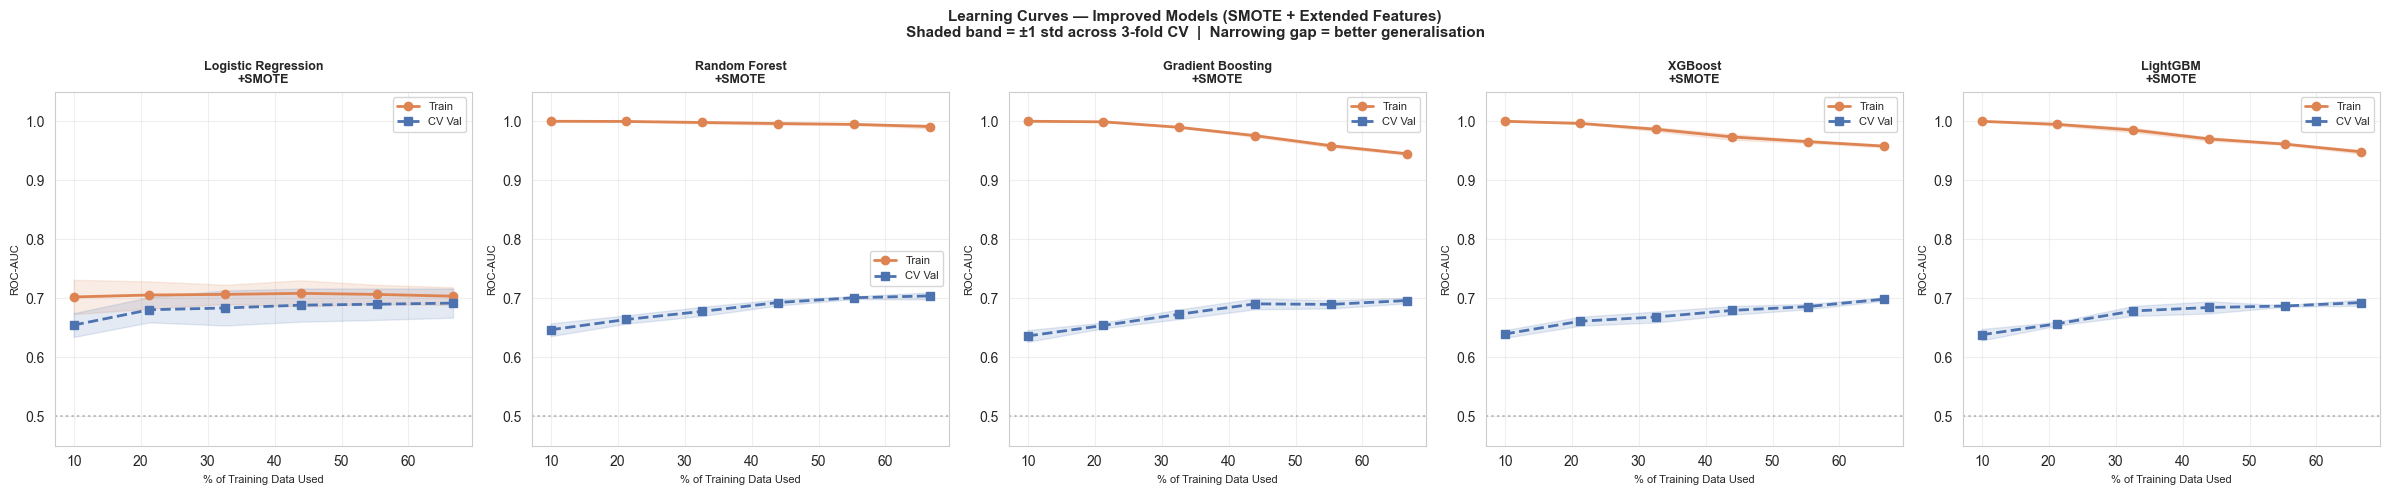


Saved: learning_curves_improved.png


In [66]:

from sklearn.model_selection import learning_curve as sk_learning_curve
from sklearn.base import clone

# ── Learning curves for all 5 improved models ─────────────────────────────
# learning_curve clones the pipeline, so SMOTE is applied correctly within
# each training fold only — test fold is never oversampled.

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
train_sizes_frac = np.linspace(0.15, 1.0, 6)

for ax, (name, pipe) in zip(axes, imp_trained_pipelines.items()):
    print(f'Learning curve: {name}...', flush=True)
    train_sizes, train_scores, val_scores = sk_learning_curve(
        clone(pipe), X_train, y_train,
        train_sizes=train_sizes_frac,
        cv=3, scoring='roc_auc',
        n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
    )
    sizes_pct  = train_sizes / len(X_train) * 100
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(sizes_pct, train_mean, 'o-',  color='#DD8452', label='Train',   linewidth=2)
    ax.fill_between(sizes_pct, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#DD8452')
    ax.plot(sizes_pct, val_mean,   's--', color='#4C72B0', label='CV Val',  linewidth=2)
    ax.fill_between(sizes_pct, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#4C72B0')

    ax.set_title(name.replace(' + SMOTE', '\n+SMOTE'), fontweight='bold', fontsize=9)
    ax.set_xlabel('% of Training Data Used', fontsize=8)
    ax.set_ylabel('ROC-AUC', fontsize=8)
    ax.set_ylim(0.45, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)

plt.suptitle(
    'Learning Curves — Improved Models (SMOTE + Extended Features)\n'
    'Shaded band = ±1 std across 3-fold CV  |  Narrowing gap = better generalisation',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('improved_outputs/images/learning_curves_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: learning_curves_improved.png')


### 5b. Per-Stage / Epoch Curves — Model-Specific

| Model | Approach |
|---|---|
| **Gradient Boosting** | `staged_predict_proba` → ROC-AUC per boosting stage (1 → 300) |
| **XGBoost / LightGBM** | Retrain with `eval_set` → log-loss per stage tracked natively |
| **Random Forest** | Retrain with increasing `n_estimators` → shows tree-count saturation |
| **Logistic Regression** | Retrain with increasing `max_iter` → convergence per epoch |


GB staged curve...
XGBoost staged curve...
LightGBM staged curve...
Random Forest tree-count curve...
Logistic Regression epoch curve...


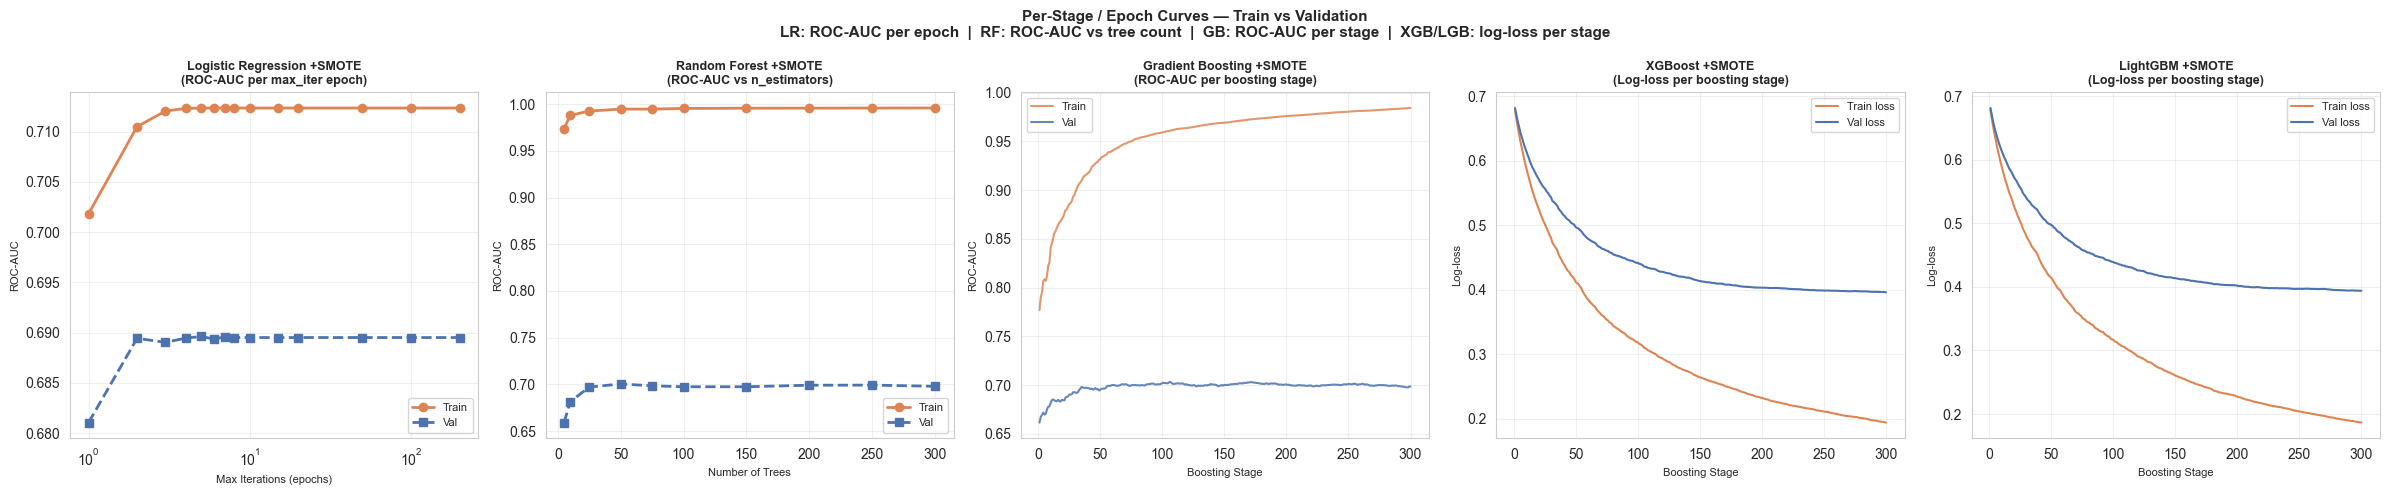


Saved: stage_epoch_curves_improved.png


In [65]:

# ── Helper: extract fitted preprocessor + SMOTE'd training data ──────────
def get_preprocessed_smote(model_name):
    """Return (X_train_sm, y_train_sm, X_test_prep) using the fitted pipeline's preprocessor."""
    pipe = imp_trained_pipelines[model_name]
    prep = pipe.named_steps['preprocessor']          # already fitted ColumnTransformer
    X_tr_prep = prep.transform(X_train)
    X_te_prep = prep.transform(X_test)
    smote_tmp = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_tr_sm, y_tr_sm = smote_tmp.fit_resample(X_tr_prep, y_train)
    return X_tr_sm, y_tr_sm, X_te_prep

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

# ── 1. Gradient Boosting: staged_predict_proba ────────────────────────────
print('GB staged curve...', flush=True)
X_tr_sm, y_tr_sm, X_te_prep = get_preprocessed_smote('Gradient Boosting + SMOTE')
clf_gb = imp_trained_pipelines['Gradient Boosting + SMOTE'].named_steps['classifier']

gb_train, gb_val = [], []
for proba in clf_gb.staged_predict_proba(X_tr_sm):
    gb_train.append(roc_auc_score(y_tr_sm, proba[:, 1]))
for proba in clf_gb.staged_predict_proba(X_te_prep):
    gb_val.append(roc_auc_score(y_test, proba[:, 1]))

stages = np.arange(1, len(gb_train) + 1)
ax = axes[2]
ax.plot(stages, gb_train, color='#DD8452', linewidth=1.5, label='Train', alpha=0.85)
ax.plot(stages, gb_val,   color='#4C72B0', linewidth=1.5, label='Val',   alpha=0.85)
ax.set_title('Gradient Boosting +SMOTE\n(ROC-AUC per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 2. XGBoost: eval_set → log-loss per stage ─────────────────────────────
print('XGBoost staged curve...', flush=True)
X_tr_sm, y_tr_sm, X_te_prep = get_preprocessed_smote('XGBoost + SMOTE')
xgb_stage = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1, verbosity=0
)
xgb_stage.fit(X_tr_sm, y_tr_sm,
               eval_set=[(X_tr_sm, y_tr_sm), (X_te_prep, y_test)],
               verbose=False)
xgb_res    = xgb_stage.evals_result_
xgb_stages = np.arange(1, len(xgb_res['validation_0']['logloss']) + 1)

ax = axes[3]
ax.plot(xgb_stages, xgb_res['validation_0']['logloss'], color='#DD8452', linewidth=1.5, label='Train loss')
ax.plot(xgb_stages, xgb_res['validation_1']['logloss'], color='#4C72B0', linewidth=1.5, label='Val loss')
ax.set_title('XGBoost +SMOTE\n(Log-loss per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('Log-loss', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 3. LightGBM: eval_set → log-loss per stage ────────────────────────────
print('LightGBM staged curve...', flush=True)
X_tr_sm, y_tr_sm, X_te_prep = get_preprocessed_smote('LightGBM + SMOTE')
lgb_stage = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_callbacks = []

import lightgbm as lgb_lib
lgb_stage.fit(X_tr_sm, y_tr_sm,
               eval_set=[(X_tr_sm, y_tr_sm), (X_te_prep, y_test)],
               eval_metric='binary_logloss',
               callbacks=[lgb_lib.record_evaluation(evals_result := {})])
lgb_stages = np.arange(1, 301)

ax = axes[4]
ax.plot(lgb_stages, list(evals_result['training']['binary_logloss']),    color='#DD8452', linewidth=1.5, label='Train loss')
ax.plot(lgb_stages, list(evals_result['valid_1']['binary_logloss']),     color='#4C72B0', linewidth=1.5, label='Val loss')
ax.set_title('LightGBM +SMOTE\n(Log-loss per boosting stage)', fontweight='bold', fontsize=9)
ax.set_xlabel('Boosting Stage', fontsize=8)
ax.set_ylabel('Log-loss', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 4. Random Forest: accuracy vs n_estimators ────────────────────────────
print('Random Forest tree-count curve...', flush=True)
X_tr_sm, y_tr_sm, X_te_prep = get_preprocessed_smote('Random Forest + SMOTE')
rf_counts = [5, 10, 25, 50, 75, 100, 150, 200, 250, 300]
rf_train, rf_val = [], []
for n in rf_counts:
    rf_tmp = RandomForestClassifier(n_estimators=n, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
    rf_tmp.fit(X_tr_sm, y_tr_sm)
    rf_train.append(roc_auc_score(y_tr_sm,  rf_tmp.predict_proba(X_tr_sm)[:, 1]))
    rf_val.append(  roc_auc_score(y_test,    rf_tmp.predict_proba(X_te_prep)[:, 1]))

ax = axes[1]
ax.plot(rf_counts, rf_train, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(rf_counts, rf_val,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Random Forest +SMOTE\n(ROC-AUC vs n_estimators)', fontweight='bold', fontsize=9)
ax.set_xlabel('Number of Trees', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── 5. Logistic Regression: ROC-AUC per epoch (max_iter) ──────────────────
print('Logistic Regression epoch curve...', flush=True)
X_tr_sm, y_tr_sm, X_te_prep = get_preprocessed_smote('Logistic Regression + SMOTE')
lr_iters = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, 50, 100, 200]
lr_train, lr_val = [], []
for mi in lr_iters:
    lr_tmp = LogisticRegression(max_iter=mi, random_state=RANDOM_STATE,
                                 class_weight=None, solver='lbfgs')
    lr_tmp.fit(X_tr_sm, y_tr_sm)
    lr_train.append(roc_auc_score(y_tr_sm, lr_tmp.predict_proba(X_tr_sm)[:, 1]))
    lr_val.append(  roc_auc_score(y_test,  lr_tmp.predict_proba(X_te_prep)[:, 1]))

ax = axes[0]
ax.plot(lr_iters, lr_train, 'o-', color='#DD8452', linewidth=2, label='Train')
ax.plot(lr_iters, lr_val,   's--',color='#4C72B0', linewidth=2, label='Val')
ax.set_title('Logistic Regression +SMOTE\n(ROC-AUC per max_iter epoch)', fontweight='bold', fontsize=9)
ax.set_xlabel('Max Iterations (epochs)', fontsize=8)
ax.set_ylabel('ROC-AUC', fontsize=8)
ax.set_xscale('log')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Per-Stage / Epoch Curves — Train vs Validation\n'
    'LR: ROC-AUC per epoch  |  RF: ROC-AUC vs tree count  |  GB: ROC-AUC per stage  |  XGB/LGB: log-loss per stage',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('improved_outputs/images/stage_epoch_curves_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: stage_epoch_curves_improved.png')


### 5c. Results Visualisation

Benchmark bar chart, ROC-AUC/F1 ranking, ROC curves, and confusion matrices for all 5 improved models.


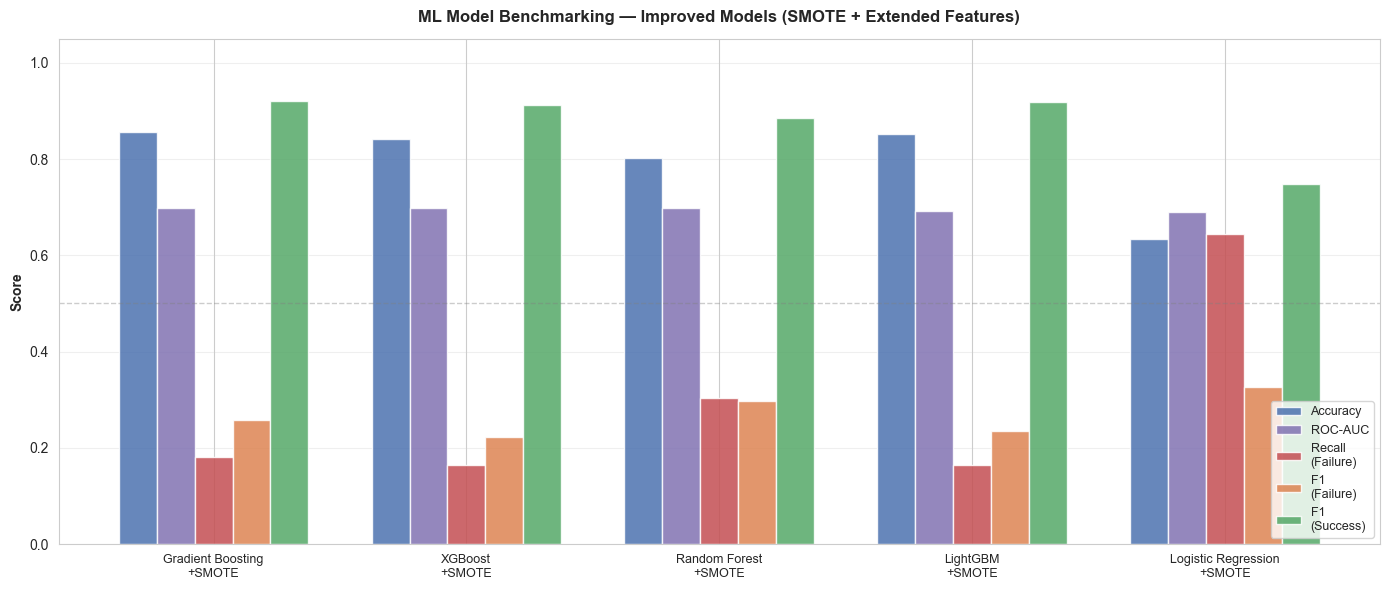

Saved: benchmark_comparison_improved.png


In [68]:

# ── Benchmark comparison bar chart — all 5 improved models ────────────────
# imp_df has per-class metrics; we plot 5 representative ones
metrics_to_plot  = ['Accuracy', 'ROC-AUC', 'Recall (Failure)', 'F1 (Failure)', 'F1 (Success)']
metric_labels    = ['Accuracy', 'ROC-AUC', 'Recall\n(Failure)', 'F1\n(Failure)', 'F1\n(Success)']
plot_imp = imp_df.set_index('Model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(plot_imp))
width = 0.15
colors_ = ['#4C72B0', '#8172B2', '#C44E52', '#DD8452', '#55A868']

for i, (metric, label, color) in enumerate(zip(metrics_to_plot, metric_labels, colors_)):
    bars_ = ax.bar(x + i * width, plot_imp[metric].values, width,
                   label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels([n.replace(' + SMOTE', '\n+SMOTE') for n in plot_imp.index],
                    rotation=0, ha='center', fontsize=9)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('ML Model Benchmarking — Improved Models (SMOTE + Extended Features)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('improved_outputs/images/benchmark_comparison_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: benchmark_comparison_improved.png')



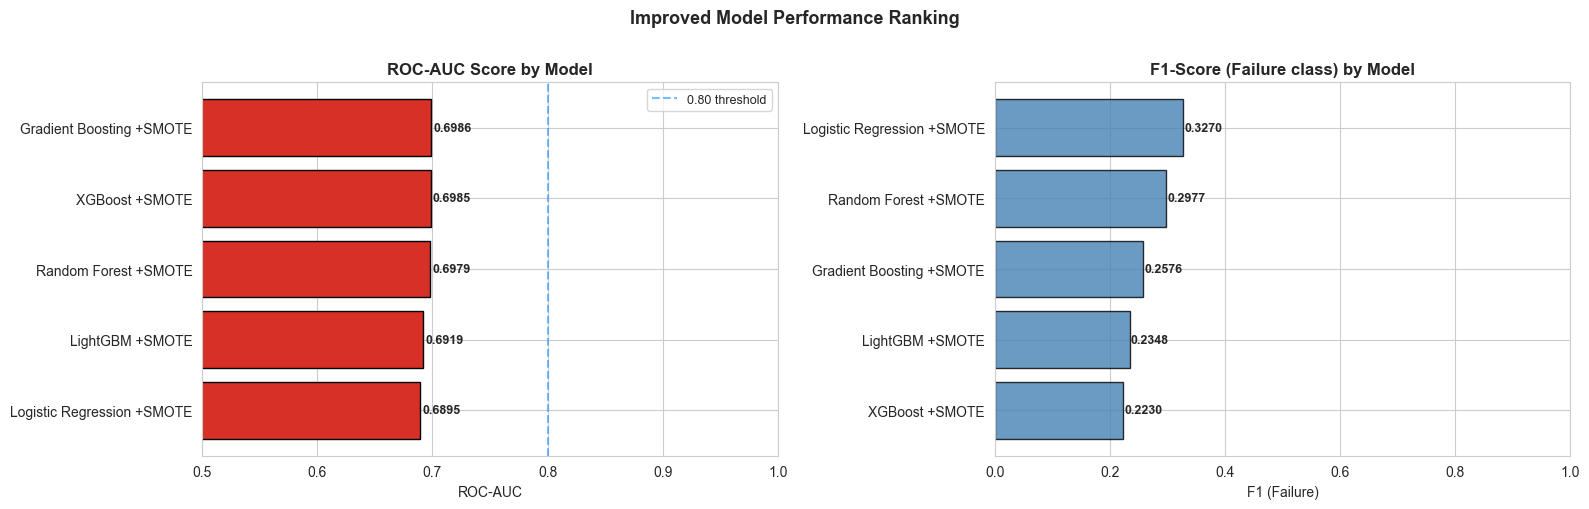

Saved: model_ranking_improved.png


In [69]:

# ── ROC-AUC & F1 (Failure) ranking ────────────────────────────────────────
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sorted_roc = imp_df.sort_values('ROC-AUC', ascending=True)
colors_roc = ['#d73027' if v < 0.70 else '#fee08b' if v < 0.80 else '#1a9850'
               for v in sorted_roc['ROC-AUC']]
bars = axes[0].barh([n.replace(' + SMOTE', ' +SMOTE') for n in sorted_roc['Model']],
                    sorted_roc['ROC-AUC'], color=colors_roc, edgecolor='black')
for bar, val in zip(bars, sorted_roc['ROC-AUC']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(0.8, color='dodgerblue', linestyle='--', alpha=0.6, label='0.80 threshold')
axes[0].legend(fontsize=9)
axes[0].set_title('ROC-AUC Score by Model', fontweight='bold')
axes[0].set_xlabel('ROC-AUC')

sorted_f1 = imp_df.sort_values('F1 (Failure)', ascending=True)
bars2 = axes[1].barh([n.replace(' + SMOTE', ' +SMOTE') for n in sorted_f1['Model']],
                     sorted_f1['F1 (Failure)'], color='steelblue', edgecolor='black', alpha=0.8)
for bar, val in zip(bars2, sorted_f1['F1 (Failure)']):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0, 1.0)
axes[1].set_title('F1-Score (Failure class) by Model', fontweight='bold')
axes[1].set_xlabel('F1 (Failure)')

plt.suptitle('Improved Model Performance Ranking', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('improved_outputs/images/model_ranking_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_ranking_improved.png')



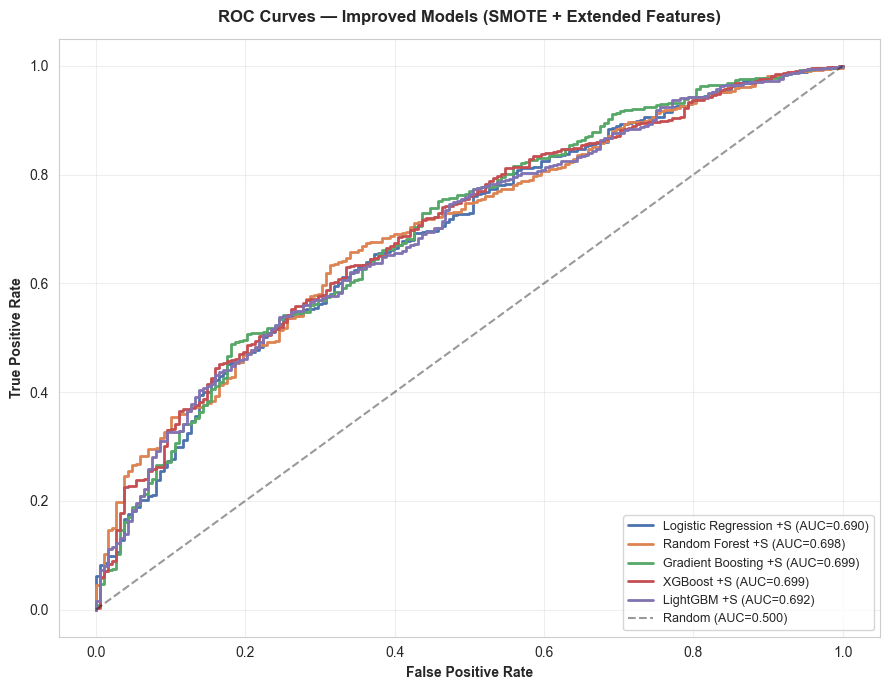

Saved: roc_curves_improved.png


In [70]:

# ── ROC Curves — all 5 improved models ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc_lines = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for (name, pipe), color in zip(imp_trained_pipelines.items(), colors_roc_lines):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    short = name.replace(' + SMOTE', ' +S')
    ax.plot(fpr, tpr, label=f'{short} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves — Improved Models (SMOTE + Extended Features)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('improved_outputs/images/roc_curves_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves_improved.png')



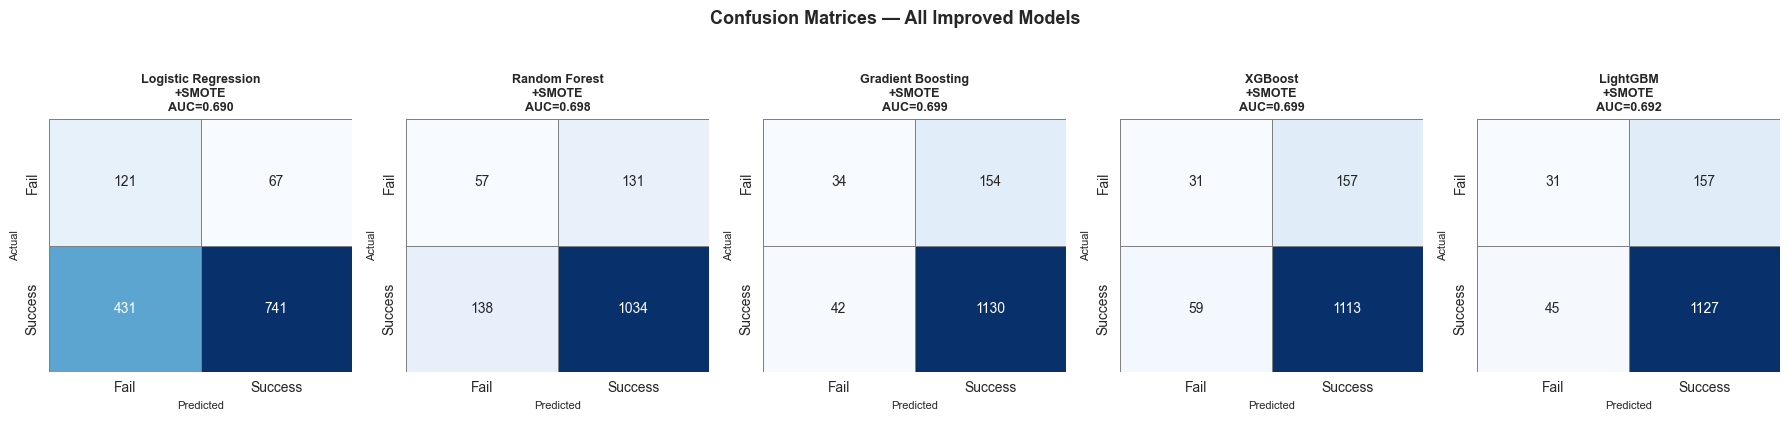

Saved: confusion_matrices_all_improved.png


In [71]:

# ── Confusion matrices grid — all 5 improved models ───────────────────────
n_imp     = len(imp_trained_pipelines)
fig, axes = plt.subplots(1, n_imp, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, imp_trained_pipelines.items()):
    yp   = pipe.predict(X_test)
    cm_  = confusion_matrix(y_test, yp)
    auc  = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])

    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fail', 'Success'], yticklabels=['Fail', 'Success'],
                linewidths=0.5, linecolor='gray', cbar=False)
    ax.set_title(f'{name.replace(" + SMOTE", chr(10)+"+SMOTE")}\nAUC={auc:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

plt.suptitle('Confusion Matrices — All Improved Models', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('improved_outputs/images/confusion_matrices_all_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices_all_improved.png')



## 6. Baseline vs Improved Comparison

In [53]:
# ── Load baseline results for comparison ──────────────────────────────────
baseline_df = pd.read_csv('baseline_outputs/ml_benchmark_results.csv')
print(f'Loaded baseline results: {len(baseline_df)} models')
print(baseline_df[['Model', 'ROC-AUC', 'F1-Score']].to_string(index=False))

Loaded baseline results: 12 models
              Model  ROC-AUC  F1-Score
          SVM (RBF) 0.696116  0.758105
           AdaBoost 0.695803  0.925750
Logistic Regression 0.691664  0.743525
  Gradient Boosting 0.688095  0.924791
 MLP Neural Network 0.688002  0.925692
            XGBoost 0.681405  0.786538
           LightGBM 0.678875  0.799237
        Extra Trees 0.672877  0.830258
      Random Forest 0.670574  0.859895
      Decision Tree 0.640551  0.694459
K-Nearest Neighbors 0.628272  0.919135
        Naive Bayes 0.624630  0.907536


In [54]:
# ── Re-train top-5 baseline models on improved split for fair comparison ──
# (Same data, same split, but baseline features only — no SMOTE)
from sklearn.linear_model import LogisticRegression as LR
from sklearn.ensemble import RandomForestClassifier as RF, GradientBoostingClassifier as GB

BASELINE_FEATURES = [
    'Age', 'Days_To_Treatment', 'Year', 'Sex', 'Anatomical Site',
    'Registration Group', 'Bacteriologic Status', 'Microscopy Result',
    'Source of Patient', 'Type', 'Province',
]

baseline_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

# Use the same df / split indices for fair comparison
X_base = df[BASELINE_FEATURES].copy()
X_base['Age'] = X_base['Age'].fillna(df['Computed_Age'])
X_base_train = X_base.loc[X_train.index]
X_base_test  = X_base.loc[X_test.index]

BASELINE_MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=RANDOM_STATE, subsample=0.8
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / y_train.sum(),
        n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, class_weight='balanced',
        n_jobs=-1, verbose=-1
    ),
}

baseline_trained = {}
for name, model in BASELINE_MODELS.items():
    pipe = Pipeline(steps=[('preprocessor', baseline_preprocessor), ('classifier', model)])
    pipe.fit(X_base_train, y_train)
    baseline_trained[name] = pipe

print(f'Re-trained {len(BASELINE_MODELS)} baseline models on same data split for fair comparison.')

Re-trained 5 baseline models on same data split for fair comparison.


In [55]:
# ── Side-by-side comparison ───────────────────────────────────────────────
baseline_lookup = {
    'Logistic Regression + SMOTE': 'Logistic Regression',
    'Random Forest + SMOTE':       'Random Forest',
    'Gradient Boosting + SMOTE':   'Gradient Boosting',
    'XGBoost + SMOTE':             'XGBoost',
    'LightGBM + SMOTE':            'LightGBM',
}

compare_rows = []
for imp_name, base_name in baseline_lookup.items():
    imp_row = imp_df[imp_df['Model'] == imp_name].iloc[0]

    # Baseline metrics from re-trained models on same split
    base_pipe = baseline_trained[base_name]
    base_pred = base_pipe.predict(X_base_test)
    base_proba = base_pipe.predict_proba(X_base_test)[:, 1]
    base_rep = classification_report(y_test, base_pred,
                                     target_names=['Failure', 'Success'],
                                     output_dict=True, zero_division=0)
    base_auc = roc_auc_score(y_test, base_proba)

    compare_rows.append({
        'Model':                     base_name,
        'Baseline ROC-AUC':          base_auc,
        'Improved ROC-AUC':          imp_row['ROC-AUC'],
        'ΔAUC':                      imp_row['ROC-AUC'] - base_auc,
        'Baseline Recall (Fail)':    base_rep['Failure']['recall'],
        'Improved Recall (Fail)':    imp_row['Recall (Failure)'],
        'ΔRecall (Fail)':            imp_row['Recall (Failure)'] - base_rep['Failure']['recall'],
    })

compare_df = pd.DataFrame(compare_rows)

print('Baseline → Improved Comparison (same data split):')
print(compare_df.to_string(index=False, float_format='{:.4f}'.format))

Baseline → Improved Comparison (same data split):
              Model  Baseline ROC-AUC  Improved ROC-AUC    ΔAUC  Baseline Recall (Fail)  Improved Recall (Fail)  ΔRecall (Fail)
Logistic Regression            0.6917            0.6895 -0.0022                  0.6543                  0.6436         -0.0106
      Random Forest            0.6706            0.6979  0.0274                  0.3085                  0.3032         -0.0053
  Gradient Boosting            0.6881            0.6986  0.0105                  0.0479                  0.1809          0.1330
            XGBoost            0.6814            0.6985  0.0171                  0.5213                  0.1649         -0.3564
           LightGBM            0.6789            0.6919  0.0130                  0.5372                  0.1649         -0.3723


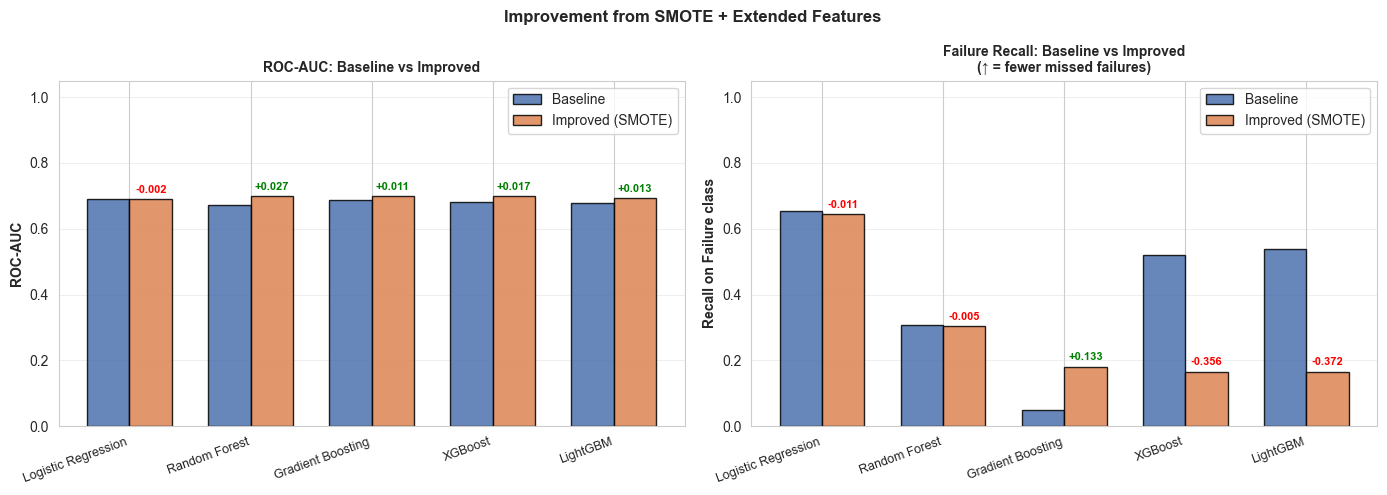

Saved: baseline_vs_improved.png


In [56]:
# ── Grouped bar chart: Baseline vs Improved ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_labels = [r.replace(' + SMOTE', '') for r in compare_df['Model']]
x = np.arange(len(model_labels))
w = 0.35

for ax, base_col, imp_col, title, ylabel in [
    (axes[0], 'Baseline ROC-AUC', 'Improved ROC-AUC', 'ROC-AUC: Baseline vs Improved', 'ROC-AUC'),
    (axes[1], 'Baseline Recall (Fail)', 'Improved Recall (Fail)',
     'Failure Recall: Baseline vs Improved\n(↑ = fewer missed failures)', 'Recall on Failure class'),
]:
    b1 = ax.bar(x - w/2, compare_df[base_col], w, label='Baseline', color='#4C72B0', alpha=0.85, edgecolor='black')
    b2 = ax.bar(x + w/2, compare_df[imp_col],  w, label='Improved (SMOTE)', color='#DD8452', alpha=0.85, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(ylabel, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)
    # Delta labels
    for xi, (bv, iv) in enumerate(zip(compare_df[base_col], compare_df[imp_col])):
        delta = iv - bv
        color = 'green' if delta > 0 else 'red'
        ax.text(xi + w/2, iv + 0.02, f'{delta:+.3f}', ha='center', fontsize=8,
                color=color, fontweight='bold')

plt.suptitle('Improvement from SMOTE + Extended Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('improved_outputs/images/baseline_vs_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline_vs_improved.png')

## 7. Best Improved Model — Detailed Analysis

In [57]:
# ── Best improved model: detailed report & confusion matrix ───────────────
best_imp_name = imp_df.iloc[0]['Model']
best_imp_pipe = imp_trained_pipelines[best_imp_name]
y_pred_best   = best_imp_pipe.predict(X_test)
y_proba_best  = best_imp_pipe.predict_proba(X_test)[:, 1]

print(f'Best improved model: {best_imp_name}')
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print()
print(classification_report(y_test, y_pred_best,
                             target_names=['Failure (0)', 'Success (1)'], zero_division=0))

Best improved model: Gradient Boosting + SMOTE
  ROC-AUC: 0.6986

              precision    recall  f1-score   support

 Failure (0)       0.45      0.18      0.26       188
 Success (1)       0.88      0.96      0.92      1172

    accuracy                           0.86      1360
   macro avg       0.66      0.57      0.59      1360
weighted avg       0.82      0.86      0.83      1360



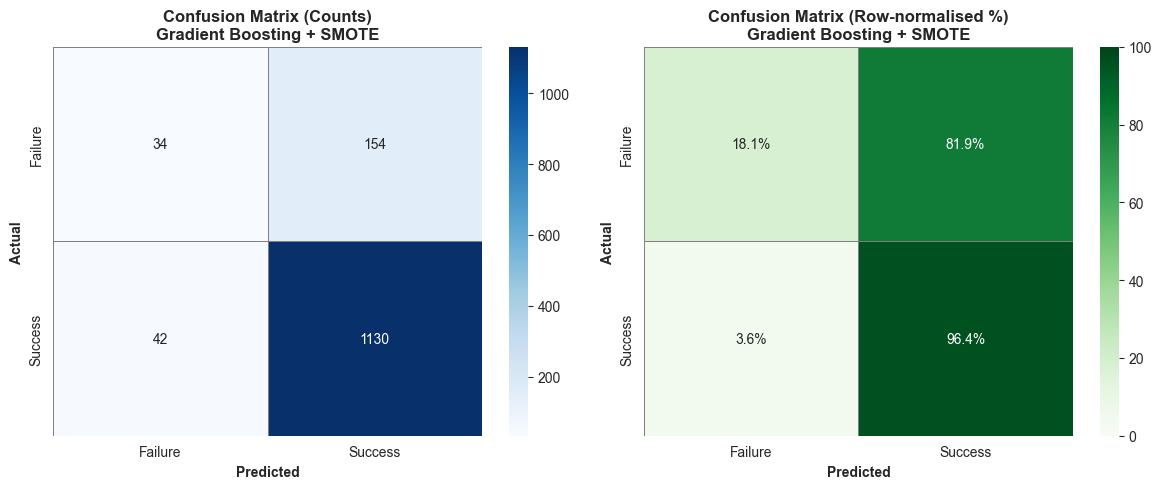

Saved: confusion_matrix_best_improved.png


In [72]:

# ── Best improved model — dual confusion matrix (counts + normalised %) ───
cm_best = confusion_matrix(y_test, y_pred_best)
cm_best_pct = cm_best.astype(float) / cm_best.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray')
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title(f'Confusion Matrix (Counts)\n{best_imp_name}', fontweight='bold')

labels_pct = [[f'{v:.1f}%' for v in row] for row in cm_best_pct]
sns.heatmap(cm_best_pct, annot=labels_pct, fmt='', cmap='Greens', ax=axes[1],
            xticklabels=['Failure', 'Success'],
            yticklabels=['Failure', 'Success'],
            linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('Actual', fontweight='bold')
axes[1].set_title(f'Confusion Matrix (Row-normalised %)\n{best_imp_name}', fontweight='bold')

plt.tight_layout()
plt.savefig('improved_outputs/images/confusion_matrix_best_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_best_improved.png')



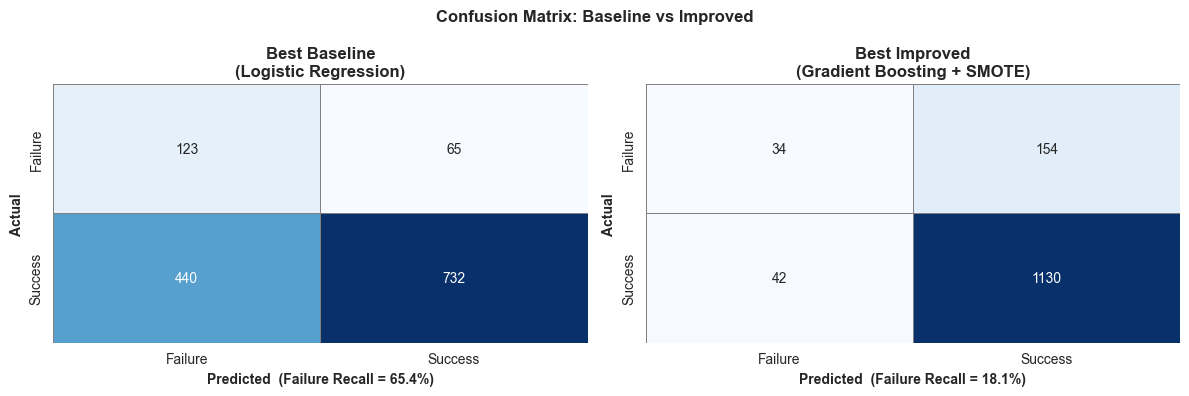

In [58]:
# ── Confusion matrices: best baseline vs best improved ────────────────────
# Find best baseline from re-trained models
best_base_auc = 0
best_base_name = ''
for name, pipe in baseline_trained.items():
    auc = roc_auc_score(y_test, pipe.predict_proba(X_base_test)[:, 1])
    if auc > best_base_auc:
        best_base_auc = auc
        best_base_name = name

best_base_pred = baseline_trained[best_base_name].predict(X_base_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
titles = [
    f'Best Baseline\n({best_base_name})',
    f'Best Improved\n({best_imp_name})',
]
test_sets = [
    (y_test, best_base_pred),
    (y_test, y_pred_best),
]

for ax, (yt, yp), title in zip(axes, test_sets, titles):
    cm_ = confusion_matrix(yt, yp)
    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Failure', 'Success'],
                yticklabels=['Failure', 'Success'],
                linewidths=0.5, linecolor='gray', cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')
    tn, fp, fn, tp = cm_.ravel()
    fail_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    ax.set_xlabel(f'Predicted  (Failure Recall = {fail_recall:.1%})', fontweight='bold')

plt.suptitle('Confusion Matrix: Baseline vs Improved', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('improved_outputs/images/cm_baseline_vs_improved.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance

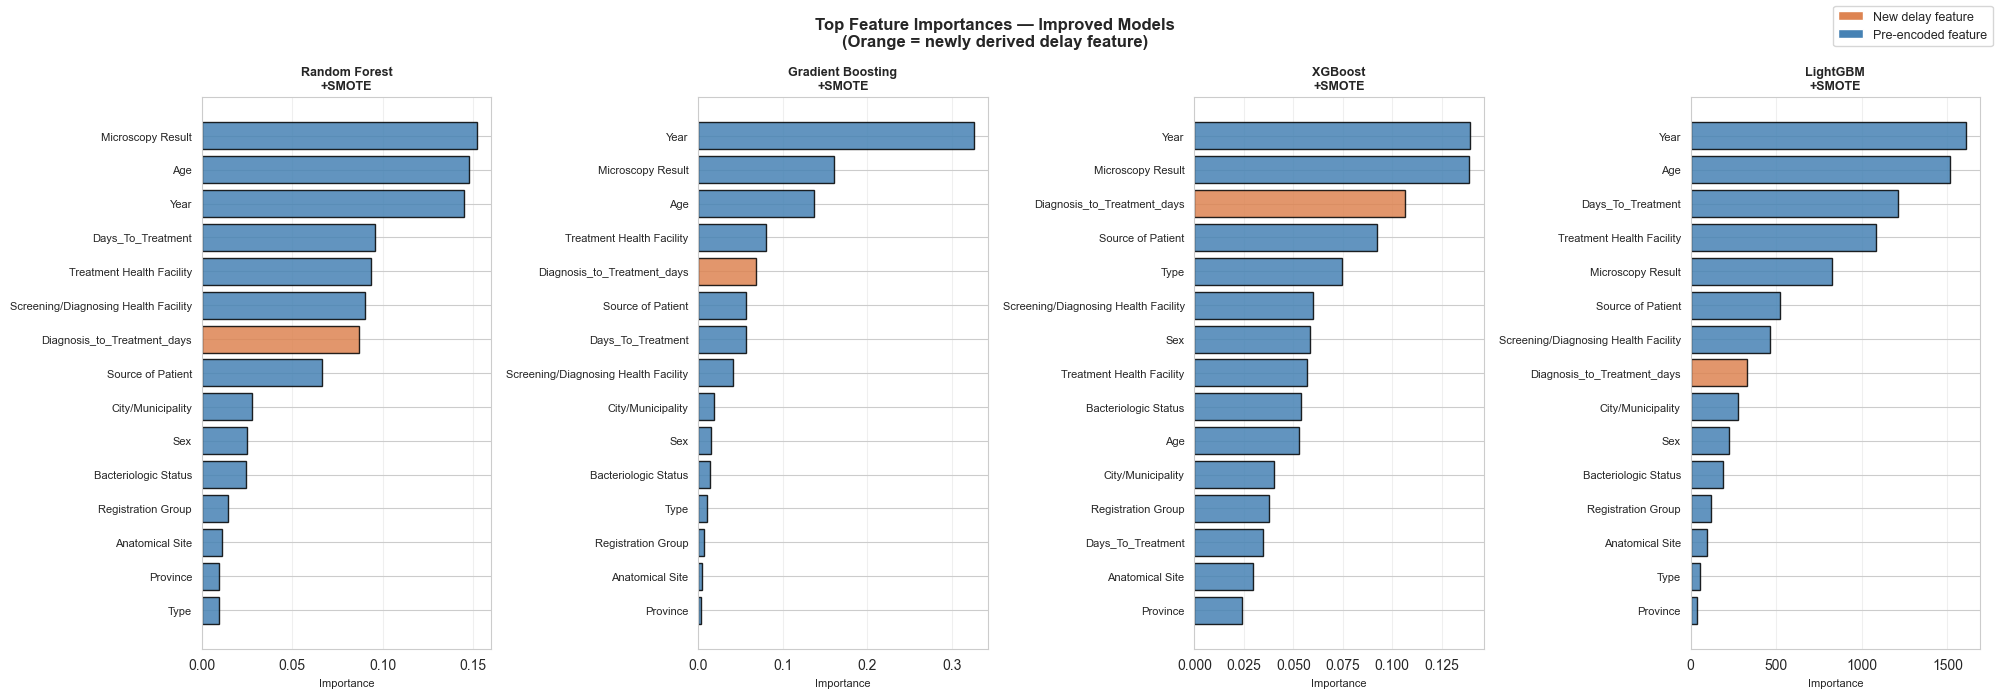

Saved: feature_importance_improved.png


In [59]:
# ── Feature importance of improved tree models ─────────────────────────────
tree_imp_models = {k: v for k, v in imp_trained_pipelines.items()
                   if any(m in k for m in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM'])}

def get_imp_feature_names(pipe):
    return PRE_ENCODED_FEATURES + DERIVED_FEATURES

fig, axes = plt.subplots(1, len(tree_imp_models), figsize=(20, 7))

for ax, (name, pipe) in zip(axes, tree_imp_models.items()):
    clf         = pipe.named_steps['classifier']
    feat_names  = get_imp_feature_names(pipe)
    importances = clf.feature_importances_

    top_n = min(15, len(feat_names))
    top_idx  = np.argsort(importances)[-top_n:]
    top_names = [feat_names[i] for i in top_idx]
    top_vals  = importances[top_idx]

    # Highlight the new delay feature in orange
    delay_feats = {'Diagnosis_to_Treatment_days'}
    colors_ = ['#DD8452' if n in delay_feats else 'steelblue' for n in top_names]

    ax.barh(range(top_n), top_vals, color=colors_, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_title(name.replace(' + SMOTE', '\n+SMOTE'), fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

# Legend
legend_elements = [Patch(facecolor='#DD8452', label='New delay feature'),
                   Patch(facecolor='steelblue', label='Pre-encoded feature')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('Top Feature Importances — Improved Models\n(Orange = newly derived delay feature)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('improved_outputs/images/feature_importance_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importance_improved.png')

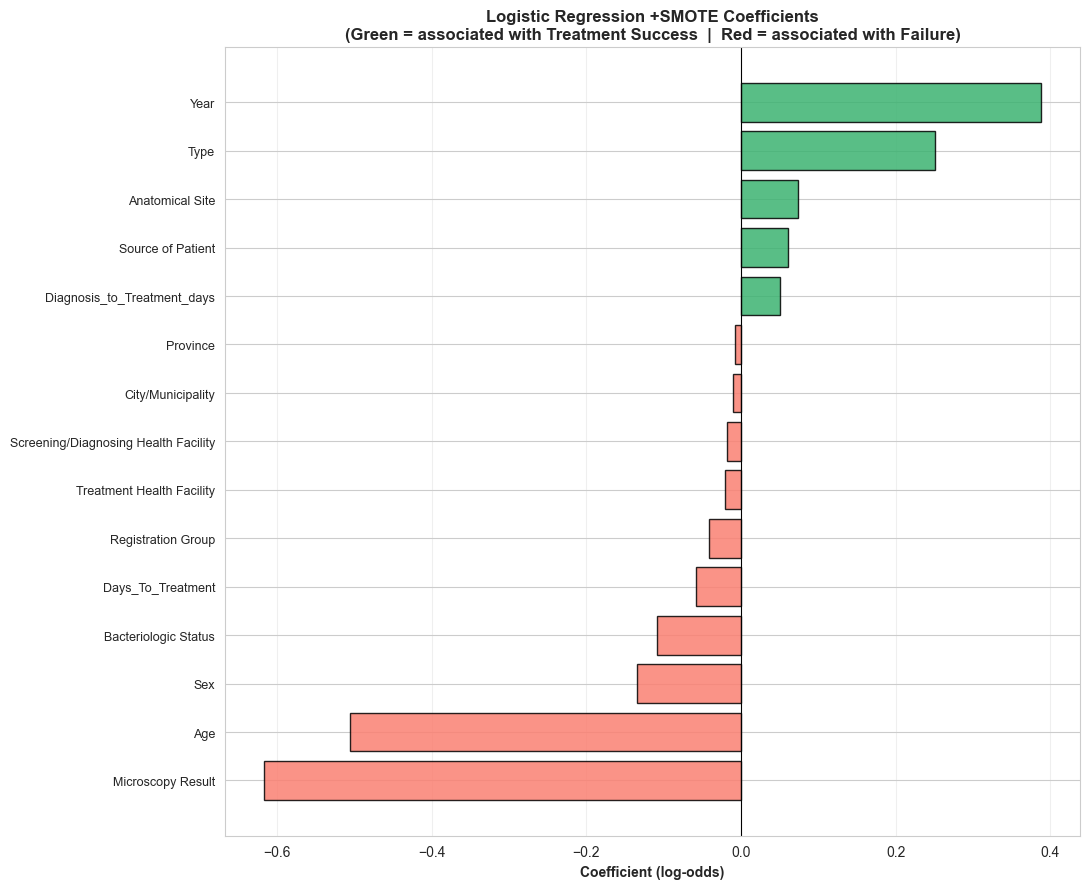

Saved: logreg_coefficients_improved.png


In [73]:

# ── Logistic Regression +SMOTE coefficients ────────────────────────────────
lr_imp_pipe = imp_trained_pipelines['Logistic Regression + SMOTE']
lr_imp_clf  = lr_imp_pipe.named_steps['classifier']
feat_names_lr = PRE_ENCODED_FEATURES + DERIVED_FEATURES

coefs_lr   = lr_imp_clf.coef_[0]
sorted_lr  = np.argsort(coefs_lr)
x_vals_lr  = coefs_lr[sorted_lr]
x_names_lr = [feat_names_lr[i] for i in sorted_lr]
colors_lr  = ['salmon' if v < 0 else 'mediumseagreen' for v in x_vals_lr]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(range(len(x_vals_lr)), x_vals_lr, color=colors_lr, edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(x_vals_lr)))
ax.set_yticklabels(x_names_lr, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)', fontweight='bold')
ax.set_title(
    'Logistic Regression +SMOTE Coefficients\n'
    '(Green = associated with Treatment Success  |  Red = associated with Failure)',
    fontweight='bold'
)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('improved_outputs/images/logreg_coefficients_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: logreg_coefficients_improved.png')



## 9. Cross-Validation — Improved Models

5-fold stratified CV on the full dataset using the same ImbPipeline (SMOTE applied inside each fold).


In [74]:

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

# ── 5-fold stratified CV — all 5 improved models ───────────────────────────
# SMOTE is inside the ImbPipeline so it is applied only on training folds.
cv_imp = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_imp_results = []

for name, pipe in imp_trained_pipelines.items():
    print(f'CV: {name}...', end=' ', flush=True)
    scores = cross_validate(
        clone(pipe), X_train, y_train, cv=cv_imp,
        scoring=['accuracy', 'f1', 'roc_auc', 'recall', 'precision'],
        n_jobs=-1
    )
    cv_imp_results.append({
        'Model':        name.replace(' + SMOTE', ' +SMOTE'),
        'CV Accuracy':  f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        'CV F1':        f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV ROC-AUC':   f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'CV Recall':    f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV Precision': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
    })
    print('done')

cv_imp_df = pd.DataFrame(cv_imp_results)
print('\n5-Fold Stratified Cross-Validation Results (Improved Models):')
print(cv_imp_df.to_string(index=False))



CV: Logistic Regression + SMOTE... done
CV: Random Forest + SMOTE... done
CV: Gradient Boosting + SMOTE... done
CV: XGBoost + SMOTE... done
CV: LightGBM + SMOTE... done

5-Fold Stratified Cross-Validation Results (Improved Models):
                     Model     CV Accuracy           CV F1      CV ROC-AUC       CV Recall    CV Precision
Logistic Regression +SMOTE 0.6413 ± 0.0120 0.7551 ± 0.0097 0.6918 ± 0.0170 0.6419 ± 0.0127 0.9170 ± 0.0048
      Random Forest +SMOTE 0.8054 ± 0.0158 0.8860 ± 0.0104 0.7077 ± 0.0187 0.8786 ± 0.0185 0.8938 ± 0.0028
  Gradient Boosting +SMOTE 0.8453 ± 0.0129 0.9136 ± 0.0077 0.7113 ± 0.0227 0.9498 ± 0.0145 0.8802 ± 0.0030
            XGBoost +SMOTE 0.8438 ± 0.0086 0.9124 ± 0.0053 0.7089 ± 0.0184 0.9443 ± 0.0108 0.8827 ± 0.0017
           LightGBM +SMOTE 0.8492 ± 0.0097 0.9161 ± 0.0059 0.7049 ± 0.0222 0.9554 ± 0.0117 0.8799 ± 0.0018


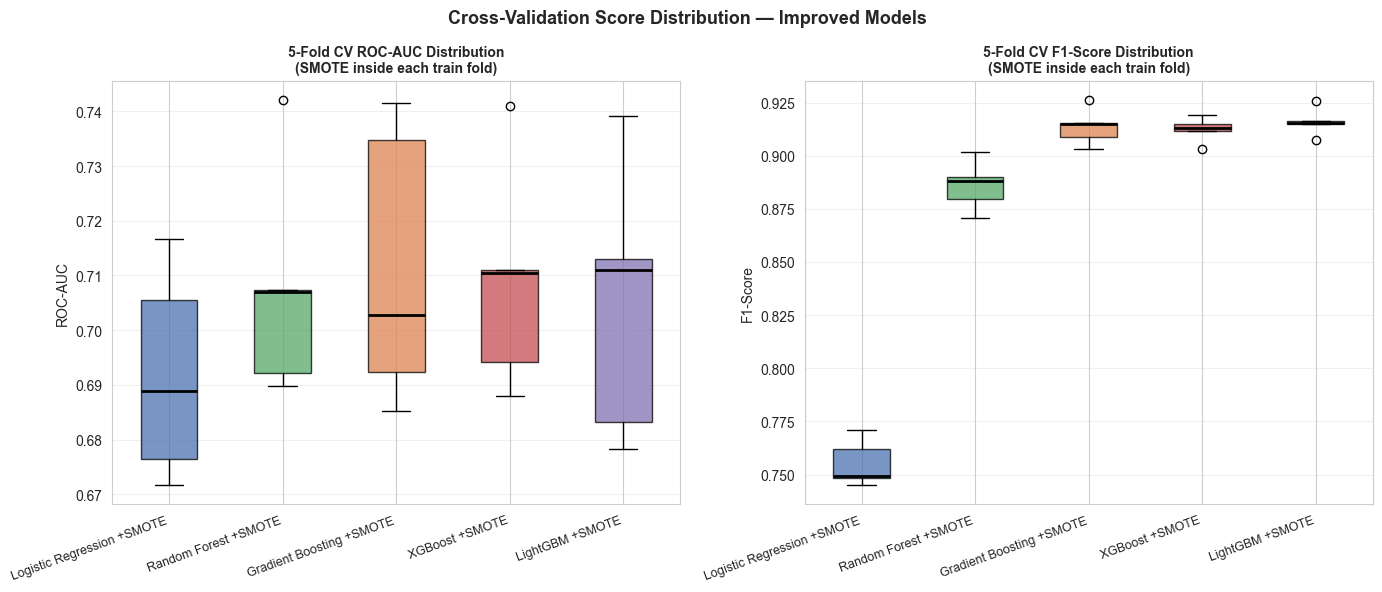

Saved: cv_boxplots_improved.png


In [75]:

# ── CV ROC-AUC & F1 boxplots ──────────────────────────────────────────────
cv_box_imp = {}
for name, pipe in imp_trained_pipelines.items():
    scores = cross_validate(clone(pipe), X_train, y_train, cv=cv_imp,
                            scoring=['roc_auc', 'f1'], n_jobs=-1)
    cv_box_imp[name.replace(' + SMOTE', ' +SMOTE')] = {
        'roc_auc': scores['test_roc_auc'],
        'f1':      scores['test_f1'],
    }

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_box_imp = ['#4C72B0', '#55A868', '#DD8452', '#C44E52', '#8172B2']

for ax, metric, title in zip(axes, ['roc_auc', 'f1'], ['ROC-AUC', 'F1-Score']):
    box_vals = [cv_box_imp[n][metric] for n in cv_box_imp]
    bp = ax.boxplot(box_vals, labels=list(cv_box_imp.keys()), patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors_box_imp):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(list(cv_box_imp.keys()), rotation=20, ha='right', fontsize=9)
    ax.set_title(f'5-Fold CV {title} Distribution\n(SMOTE inside each train fold)',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel(title)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Validation Score Distribution — Improved Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('improved_outputs/images/cv_boxplots_improved.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_boxplots_improved.png')



## 9. Save Results

In [60]:
# ── Save improved best model and results ──────────────────────────────────
safe_name = best_imp_name.replace(' ', '_').replace('(', '').replace(')', '').replace('+', 'plus')
joblib.dump(best_imp_pipe, f'improved_outputs/models/improved_best_{safe_name}.pkl')
imp_df.to_csv('improved_outputs/improved_model_results.csv', index=False)
compare_df.to_csv('improved_outputs/baseline_vs_improved_comparison.csv', index=False)

print(f'Saved improved best model   : improved_outputs/models/improved_best_{safe_name}.pkl')
print(f'Saved improved results      : improved_outputs/improved_model_results.csv')
print(f'Saved comparison summary    : improved_outputs/baseline_vs_improved_comparison.csv')

Saved improved best model   : improved_outputs/models/improved_best_Gradient_Boosting_plus_SMOTE.pkl
Saved improved results      : improved_outputs/improved_model_results.csv
Saved comparison summary    : improved_outputs/baseline_vs_improved_comparison.csv


## 10. Summary

In [61]:
# ── Improvement summary ───────────────────────────────────────────────────
print('='*70)
print('  IMPROVEMENT SUMMARY')
print('='*70)
print(f'  Dataset : 2015-2025-ml-ready.csv (pre-encoded & scaled)')
print(f'  Records : {len(df):,} (Success: {y.sum():,} | Failure: {(y==0).sum():,})')
print(f'  Features: {len(IMP_FEATURES)} (baseline {len(IMP_FEATURES)-4} + 3 geographic + 1 derived delay)')
print(f'  Split   : 80% train / 20% test (stratified) + SMOTE on train set')
print()
print(f'  Best Improved Model: {best_imp_name}')
print(f'  ROC-AUC: {imp_df.iloc[0]["ROC-AUC"]:.4f}')
print()
for _, row in compare_df.iterrows():
    auc_arrow  = '↑' if row['ΔAUC'] > 0 else '↓'
    rec_arrow  = '↑' if row['ΔRecall (Fail)'] > 0 else '↓'
    print(f"  {row['Model']:<25}  "
          f"AUC {row['Baseline ROC-AUC']:.3f}→{row['Improved ROC-AUC']:.3f} ({auc_arrow}{abs(row['ΔAUC']):.3f})  "
          f"FailRecall {row['Baseline Recall (Fail)']:.3f}→{row['Improved Recall (Fail)']:.3f} ({rec_arrow}{abs(row['ΔRecall (Fail)']):.3f})")
print('='*70)
print()
print('  Outputs saved to improved_outputs/')
print('    • improved_model_results.csv')
print('    • baseline_vs_improved_comparison.csv')
print('    • models/improved_best_*.pkl')
print('    • images/*.png')
print('='*70)

  IMPROVEMENT SUMMARY
  Dataset : 2015-2025-ml-ready.csv (pre-encoded & scaled)
  Records : 6,797 (Success: 5,858 | Failure: 939)
  Features: 15 (baseline 11 + 3 geographic + 1 derived delay)
  Split   : 80% train / 20% test (stratified) + SMOTE on train set

  Best Improved Model: Gradient Boosting + SMOTE
  ROC-AUC: 0.6986

  Logistic Regression        AUC 0.692→0.690 (↓0.002)  FailRecall 0.654→0.644 (↓0.011)
  Random Forest              AUC 0.671→0.698 (↑0.027)  FailRecall 0.309→0.303 (↓0.005)
  Gradient Boosting          AUC 0.688→0.699 (↑0.011)  FailRecall 0.048→0.181 (↑0.133)
  XGBoost                    AUC 0.681→0.699 (↑0.017)  FailRecall 0.521→0.165 (↓0.356)
  LightGBM                   AUC 0.679→0.692 (↑0.013)  FailRecall 0.537→0.165 (↓0.372)

  Outputs saved to improved_outputs/
    • improved_model_results.csv
    • baseline_vs_improved_comparison.csv
    • models/improved_best_*.pkl
    • images/*.png
